## Algorithm 1

In [1]:
import pyro
import torch
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS

In [2]:
def get_fixed_quartets(N:int, B:int, seed:int = 42):
    """this function generates random indices for quartets from total possible quartets,
    Number of quartets generated is decided by quartet bugdet B.
    
    Args:
    N: Number of leaves/taxa
    B: quartet budget (subset of quartets)
    seed: Manual seed to ensure that the subset is truly fixed
    
    Returns:
    torch.Tensor: a torch tensor of shape [B,4] containing taxa indices"""

    #setting seed
    torch.manual_seed(seed)

    quartets = [] #empty list

    for _ in range (B):
        #at each step sample 4 unique indices from available taxa
        q = torch.randperm(N)[:4] #each q is a 1D tensor with 4 integers #shape [4]
        quartets.append(q)

        #stack all the quartets into a single tensor of shape [B,4]
    return torch.stack(quartets)  


In [3]:
def compute_distance_matrix(x, eps=1e-7):
    # x can be [N, K] or [num_samples, N, K]
    is_batched = (x.dim() == 3)
    
    # Compute squared norms along the very last axis (K)
    x_sq_norm = torch.sum(x**2, dim=-1, keepdim=True) # Shape: [N, 1] or [S, N, 1]
    
    if is_batched:
        # Pairwise squared Euclidean distances handling the batch dimension
        # x: [S, N, K] -> x.unsqueeze(2): [S, N, 1, K], x.unsqueeze(1): [S, 1, N, K]
        dist_sq = torch.sum((x.unsqueeze(2) - x.unsqueeze(1)) ** 2, dim=-1) # [S, N, N]
        
        # Denominator broadcasting for 3D: [S, N, 1, 1] * [S, 1, N, 1]
        denom = (1 - x_sq_norm.unsqueeze(2)) * (1 - x_sq_norm.unsqueeze(1)) # [S, N, N, 1]
        denom = denom.squeeze(-1) # Drop the trailing 1 -> [S, N, N]
    else:
        # Your original 2D logic
        dist_sq = torch.sum((x.unsqueeze(1) - x.unsqueeze(0)) ** 2, dim=-1) # [N, N]
        denom = (1 - x_sq_norm.unsqueeze(1)) * (1 - x_sq_norm.unsqueeze(0)).squeeze(-1) # [N, N]

    # The rest of the Poincaré distance formula works perfectly for both shapes
    arg = 1 + 2 * dist_sq / torch.clamp(denom, min=eps)
    return torch.acosh(torch.clamp(arg, min=1.0 + eps))

In [4]:
def soft_four_point_penalty (D:torch.Tensor, sampled_quartets:torch.Tensor, tau =0.1):
    """this function computes the soft four point penalty for each quartet p(q;D) and sums it up for the entire subset of quartets to give total penalty.
    This penalty is small when the sums are tree like (s1 <s2=s3) , large when one of the sum is largest."""

    #1. Extracting distances for each quartet (a,b,c,d)
    a, b, c, d =  sampled_quartets[: ,0] , sampled_quartets[: ,1], sampled_quartets[: ,2], sampled_quartets[: ,3]

    #2. Computing the sums s1, s2, s3 #[B]
    s1= D[a,b] + D[c,d]
    s2= D[a,c] + D[b,d]
    s3 = D[a,d] + D[b,c]

    sums = torch.stack([s1,s2,s3], dim= -1) #shape : [B,3]

    #3. Computing the differentiable penalty
    # we want to compare each s_k with other two sums 
    penalty = 0

    for k in range(3):
        #current sum
        s_curr = sums[:, k]

        other_indices = [j for j in range(3) if j != k]
        #other two sums
        s_other1 = sums[:, other_indices[0]]
        s_other2 = sums[:, other_indices[1]]

        #computing zeta_tau(s_k - s_j) for both other sums
        #z1 = zeta_tau(s1-s2) ; z2 =zeta_tau(s1-s3)
        z1 = tau* torch.log(1+torch.exp((s_curr-s_other1)/tau))
        z2 = tau* torch.log(1+torch.exp((s_curr-s_other2)/tau))

        #penalty for this quartet computed by multiplying zeta of this value of k
        penalty += (z1*z2) #sums the penalties across k=0 to 2
    
    return penalty #p(q ; D)

## Generative Model

In [5]:
class PhylogeneticPrior:
    def __init__(self, N, K, B, seed=42):
        # 1. We fix N, K, and B  in the Setup Zone
        self.N = N
        self.K = K
        self.B = B
        # 2. We generate the fixed indices  
        self.fixed_indices = get_fixed_quartets(N, B, seed)



    def model(self, lmbda=1.0, sigma_u=1.0, tau=0.1):
        """This function represents the generative model, which creates a computational graph
        which can be used by NUTS sampler.
    
        Args:
        fixed_indices : fixed quartets obtained in previous step
        sigma_u: scale of the unconstrained Guassian base prior
        B: sampled quartet subset 
        lmbda: four-point penalty strength
        tau: smoothness temperature

        Returns:
        D: Induced pairwise distance matrix
"""

        #1. Base prior: Sample unconstrained latent vectors from Guassian distribution
        #expanding u to a N x K matrix and treating both dimensions as one joint object not independent
        #N x K
        # N and K are inferred from your fixed_indices and desired latent dimension

    
        u = pyro.sample("u",
                     dist.Normal(0, sigma_u).expand([self.N, self.K]).to_event(1)) #samples from guassian distribution, 
            #expanded to [N,K] #to_event(1) ensures N independent vectors each with K dimensions


         #2. Hyperbolic mapping to Poincarè model 
        u_norm = torch.norm(u, p=2 , dim=-1, keepdim=True) # Euclidean norm , along K axis (for each N taxa, computes norm across K features)
        # N x 1
        #we stabilize the denominator to prevent division by 0
        u_norm_stable = torch.clamp(u_norm, min=1e-7)  #if u_norm[i] < 1e-7 → replace it with eps
   
        x_direction = u / u_norm_stable #unit vector in euclidean space
        x_magnitude = torch.tanh(u_norm) #squashed magnitude [0,1]
    
        x = x_direction * x_magnitude
        # [N,1] * [N,K] / [ N,1] => [N,K]


        #3. Computing pairwise distance matrix D
        #using existing function
        D = compute_distance_matrix(x)

        #4. Compute Penalty (Differentiable Four-Point Condition)
        individiual_q_penalties = soft_four_point_penalty(D, self.fixed_indices, tau)

        #5.total penalty P(D) - mean
        avg_penalty = individiual_q_penalties.mean()

        #6. Computing potential energy
        #pyro.sample automatically creates $-\log p_0(U)$ part
        #U(U) = -log p0(U) + lambda * P_hat(D)
        pyro.factor("tree_force", -lmbda * avg_penalty)

        return D


## Running the MCMC chain




# Running for single chain

In [7]:
from pyro.infer import MCMC, NUTS

#initializing the class
N_taxa = 50
K_dim = 2
B_budget = 10
experiment = PhylogeneticPrior(N=N_taxa, K=K_dim, B=B_budget)


# Setup the kernel for the first run
nuts_kernel_single = NUTS(experiment.model)

# Instantiate MCMC with 1 chain
mcmc_single = MCMC(
    nuts_kernel_single, 
    num_samples=50, 
    warmup_steps=30, 
    num_chains=1
)

mcmc_single.run()

Sample: 100%|██████████| 80/80 [00:09,  8.62it/s, step size=2.87e-01, acc. prob=0.573]


## Evaluation and calibration phase

### Checking sampler health diagnostics

In [9]:
mcmc_single.summary()



                mean       std    median      5.0%     95.0%     n_eff     r_hat
    u[0,0]      0.15      0.83      0.11     -1.07      1.36     18.32      0.99
    u[0,1]     -0.25      0.56     -0.21     -1.20      0.52     18.09      1.12
    u[1,0]      0.11      0.57      0.10     -0.89      1.00     23.87      0.98
    u[1,1]     -0.16      0.78     -0.07     -1.54      0.65     25.30      0.98
    u[2,0]      0.15      0.70      0.28     -0.88      1.11     23.00      1.00
    u[2,1]     -0.04      0.72     -0.19     -1.07      1.04     23.81      1.03
    u[3,0]      0.01      0.83     -0.18     -1.30      1.26     38.76      1.03
    u[3,1]     -0.20      0.76     -0.27     -1.35      0.91     45.19      0.99
    u[4,0]     -0.05      0.75     -0.19     -1.48      0.90     30.31      0.98
    u[4,1]      0.35      1.17      0.28     -1.63      2.01     31.79      0.98
    u[5,0]      0.22      0.96      0.30     -1.65      1.33     45.36      0.99
    u[5,1]      0.03      0

### Post sampling geometric diagnostics


In [10]:
# generating test data
import numpy as np
def get_fresh_test_quartets(N: int, B_test: int = 1000, seed: int = 999):
    """
    Generates a completely separate, random set of validation quartets.
    Ensures that a < b < c < d to conform to the mathematical definition.
    """
    torch.manual_seed(seed)
    np.random.seed(seed)
    test_quartets = []
    
    while len(test_quartets) < B_test:
        q = np.random.choice(N, size=4, replace=False)
        q.sort()  # Maintain strict ordering structural check: a < b < c < d
        test_quartets.append(torch.tensor(q, dtype=torch.long))
        
    return torch.stack(test_quartets)

In [11]:
#calculating hard metric tree violations and gaps

def evaluate_tree_geometry(D_full_matrices, test_quartets):
    """
    Iterates through MCMC distance matrix samples and calculates hard
    four-point violations and quartet resolution gaps on fresh test data.
    """
    # Slice the fresh test coordinates
    a = test_quartets[:, 0]
    b = test_quartets[:, 1]
    c = test_quartets[:, 2]
    d = test_quartets[:, 3]
    
    all_medians_vq = []
    all_95th_vq = []
    all_medians_gq = []
    
    # Loop over each individual sample generated during the MCMC run
    for D in D_full_matrices:
        # Calculate the 3 path sum combinations for this distance matrix [B_test]
        s1 = D[a, b] + D[c, d]
        s2 = D[a, c] + D[b, d]
        s3 = D[a, d] + D[b, c]
        
        # Stack and sort along the last dimension to find s_(1) <= s_(2) <= s_(3)
        sums_stacked = torch.stack([s1, s2, s3], dim=-1) # Shape: [B_test, 3]
        sums_sorted, _ = torch.sort(sums_stacked, dim=-1)
        
        s_1 = sums_sorted[:, 0] # Minimum quartet sum
        s_2 = sums_sorted[:, 1] # Intermediate quartet sum
        s_3 = sums_sorted[:, 2] # Maximum quartet sum
        
        # 1. Hard violation calculation: v_q = s_(3) - s_(2) 
        v_q = s_3 - s_2
        
        # 2. Quartet separation resolution gap calculation: g_q = s_(2) - s_(1) 
        g_q = s_2 - s_1
        
        # Convert to numpy arrays for calculation profiling
        v_q_np = v_q.detach().numpy()
        g_q_np = g_q.detach().numpy()
        
        all_medians_vq.append(np.median(v_q_np))
        all_95th_vq.append(np.percentile(v_q_np, 95))
        all_medians_gq.append(np.median(g_q_np))
        
    return {
        "mean_median_vq": np.mean(all_medians_vq),
        "mean_95th_vq": np.mean(all_95th_vq),
        "mean_median_gq": np.mean(all_medians_gq)
    }

In [12]:
print("\n--- Running Post-Sampling Geometric Diagnostics ---")

# 1. Pull the raw coordinate samples out of the finished MCMC chain
samples = mcmc_single.get_samples()
u_samples = samples["u"] # Shape: [50, 50, 2] -> [num_samples, N_taxa, K_dim]

# 2. Map all samples downstream to full N x N distance matrices via your 3D logic
# We call your verified compute_distance_matrix using the batched samples tensor
with torch.no_grad():
    # Re-run mapping logic natively over the full trace tensor
    u_norm = torch.norm(u_samples, p=2, dim=-1, keepdim=True)
    u_norm_stable = torch.clamp(u_norm, min=1e-7)
    x_samples = (u_samples / u_norm_stable) * torch.tanh(u_norm)
    
    # Materialize the trace of complete distance matrices D [Shape: 50, 50, 50]
    D_matrices_trace = compute_distance_matrix(x_samples)

# 3. Generate 1,000 completely separate test quartets
fresh_quartets = get_fresh_test_quartets(N=N_taxa, B_test=1000, seed=123)

# 4. Extract tree metrics
geo_metrics = evaluate_tree_geometry(D_matrices_trace, fresh_quartets)

print(f"Validation Median Hard Violation (v_q): {geo_metrics['mean_median_vq']:.4f}")
print(f"Validation 95th Percentile Violation (v_q): {geo_metrics['mean_95th_vq']:.4f}")
print(f"Validation Internal Branch Gap (g_q): {geo_metrics['mean_median_gq']:.4f}")





--- Running Post-Sampling Geometric Diagnostics ---
Validation Median Hard Violation (v_q): 0.3276
Validation 95th Percentile Violation (v_q): 1.0502
Validation Internal Branch Gap (g_q): 1.4946


In [13]:
import torch
import numpy as np

def compute_advanced_diagnostics(D_trace, test_quartets, delta=0.05, gamma=0.1):
    """
    Computes rigorous out-of-sample phylogenetic diagnostics.
    
    Args:
        D_trace (torch.Tensor): Trace of materialized distance matrices. 
                                Shape: [num_samples, N_taxa, N_taxa]
        test_quartets (torch.Tensor): Unseen validation quartets. Shape: [B_test, 4]
        delta (float): Maximum tolerance threshold for a quartet to be considered 
                       "tree-consistent" (Section 12.3). Default: 0.05
        gamma (float): Minimum branch length threshold for a quartet to be considered 
                       "cleanly resolved" rather than a star-tree (Section 12.4). Default: 0.1
                       
    Returns:
        dict: High-level academic tree metrics.
    """
    N_taxa = D_trace.shape[-1]
    
    # 1. Vectorized extraction of validation quartet indices
    a = test_quartets[:, 0]
    b = test_quartets[:, 1]
    c = test_quartets[:, 2]
    d = test_quartets[:, 3]
    
    # Accumulation lists across all saved MCMC samples
    consistency_rates = []
    gap_5th_percentiles = []
    resolved_rates = []
    
    dist_means = []
    dist_mins = []
    dist_maxs = []
    dist_q25s = []
    dist_q75s = []
    
    # Extract strictly non-redundant upper-triangle indices for pairwise leaf distances
    triu_i, triu_j = torch.triu_indices(N_taxa, N_taxa, offset=1)
    
    # Loop over each individual distance matrix sample in the NUTS trace
    for D in D_trace:
        
        # -----------------------------------------------------------------
        # COMPONENT 1: FOUR-POINT CONDITION & TREE-CONSISTENCY (Section 12.3)
        # -----------------------------------------------------------------
        s1 = D[a, b] + D[c, d]
        s2 = D[a, c] + D[b, d]
        s3 = D[a, d] + D[b, c]
        
        # Stack and sort combinations to find s_(1) <= s_(2) <= s_(3)
        sums_stacked = torch.stack([s1, s2, s3], dim=-1) # Shape: [B_test, 3]
        sums_sorted, _ = torch.sort(sums_stacked, dim=-1)
        
        s_1 = sums_sorted[:, 0]
        s_2 = sums_sorted[:, 1]
        s_3 = sums_sorted[:, 2]
        
        # Hard violation definition: v_q = s_(3) - s_(2)
        v_q = (s_3 - s_2).detach().numpy()
        
        # Tree-Consistency Rate: Fraction of quartets satisfying additivity within delta
        c_rate = np.mean(v_q <= delta)
        consistency_rates.append(c_rate)
        
        # -----------------------------------------------------------------
        # COMPONENT 2: QUARTET GAP TAIL DISTRIBUTION AUDIT (Section 12.4)
        # -----------------------------------------------------------------
        # Resolution gap definition: g_q = s_(2) - s_(1)
        g_q = (s_2 - s_1).detach().numpy()
        
        # 5th percentile catches the tail of near-star trees (star-tree collapse risk)
        gap_5th = np.percentile(g_q, 5)
        gap_5th_percentiles.append(gap_5th)
        
        # Resolved Rate: Fraction of validation quartets with a distinct internal branch >= gamma
        r_rate = np.mean(g_q >= gamma)
        resolved_rates.append(r_rate)
        
        # -----------------------------------------------------------------
        # COMPONENT 3: EMPIRICAL DISTANCE-SCALE DIAGNOSTICS (Section 12.5)
        # -----------------------------------------------------------------
        # Isolate all distinct off-diagonal pairwise leaf distances {D_ij}
        pairwise_dists = D[triu_i, triu_j].detach().numpy()
        
        dist_means.append(np.mean(pairwise_dists))
        dist_mins.append(np.min(pairwise_dists))
        dist_maxs.append(np.max(pairwise_dists))
        dist_q25s.append(np.percentile(pairwise_dists, 25))
        dist_q75s.append(np.percentile(pairwise_dists, 75))
        
    # 2. Average the summary statistics across your entire posterior matrix trace
    return {
        "tree_consistency_rate": float(np.mean(consistency_rates)),
        "gap_5th_percentile": float(np.mean(gap_5th_percentiles)),
        "resolved_quartet_rate": float(np.mean(resolved_rates)),
        "distance_scale": {
            "mean_D_ij": float(np.mean(dist_means)),
            "min_D_ij": float(np.mean(dist_mins)),
            "max_D_ij": float(np.mean(dist_maxs)),
            "q25_D_ij": float(np.mean(dist_q25s)),
            "q75_D_ij": float(np.mean(dist_q75s))
        }
    }

In [14]:
# 1. Project your saved latent coordinates 'u' out to full distance matrices
samples_u = mcmc_single.get_samples()["u"]

with torch.no_grad():
    u_norm = torch.norm(samples_u, p=2, dim=-1, keepdim=True)
    u_norm_stable = torch.clamp(u_norm, min=1e-7)
    x_samples = (samples_u / u_norm_stable) * torch.tanh(u_norm)
    
    # Uses your existing 3D compute_distance_matrix function
    D_trace_matrices = compute_distance_matrix(x_samples)

# 2. Generate your unseen validation test benchmark set
# (Assuming get_fresh_test_quartets is already loaded in your notebook)
validation_quartets = get_fresh_test_quartets(N=50, B_test=1000, seed=123)

# 3. Calculate all advanced metrics
advanced_metrics = compute_advanced_diagnostics(
    D_trace_matrices, 
    validation_quartets, 
    delta=0.05, 
    gamma=0.1
)

# 4. Print the output summary
print("--- ADVANCED ACADEMIC TREE DIAGNOSTICS ---")
print(f"Tree-Consistency Rate (v_q <= 0.05): {advanced_metrics['tree_consistency_rate']:.4%}")
print(f"5th Percentile Quartet Gap (g_q):     {advanced_metrics['gap_5th_percentile']:.4f}")
print(f"Cleanly Resolved Quartet Proportion:  {advanced_metrics['resolved_quartet_rate']:.4%}")
print("\n--- DISTANCE SCALE DISTRIBUTIONS {D_ij} ---")
print(f"Minimum Distance: {advanced_metrics['distance_scale']['min_D_ij']:.4f}")
print(f"25th Percentile:  {advanced_metrics['distance_scale']['q25_D_ij']:.4f}")
print(f"Mean Distance:     {advanced_metrics['distance_scale']['mean_D_ij']:.4f}")
print(f"75th Percentile:  {advanced_metrics['distance_scale']['q75_D_ij']:.4f}")
print(f"Maximum Distance: {advanced_metrics['distance_scale']['max_D_ij']:.4f}")

--- ADVANCED ACADEMIC TREE DIAGNOSTICS ---
Tree-Consistency Rate (v_q <= 0.05): 12.3800%
5th Percentile Quartet Gap (g_q):     0.1226
Cleanly Resolved Quartet Proportion:  95.8400%

--- DISTANCE SCALE DISTRIBUTIONS {D_ij} ---
Minimum Distance: 0.1234
25th Percentile:  2.5474
Mean Distance:     3.9812
75th Percentile:  5.2411
Maximum Distance: 10.5864


In [15]:
def compute_geometric_diagnostics(D_trace, test_quartets, delta=0.05, gamma=0.1):
    """
    Unified post-sampling geometric diagnostics over a trace of distance matrices.

    Covers Sections 12.2–12.5 of the paper:
      - Four-point violation quantiles       (12.2)
      - Tree-consistency rate                (12.3)
      - Quartet gap distribution             (12.4)
      - Pairwise distance-scale summaries    (12.5)

    Args:
        D_trace       : Tensor [S, N, N] — trace of distance matrices from NUTS
        test_quartets : Tensor [B, 4]   — held-out validation quartets (not used in penalty)
        delta         : float — violation tolerance for tree-consistency rate (12.3)
        gamma         : float — minimum gap threshold for "resolved" quartet  (12.4)

    Returns:
        dict with all diagnostics, averaged across the S trace samples.
    """
    a, b, c, d = (test_quartets[:, k] for k in range(4))
    N = D_trace.shape[-1]
    triu_i, triu_j = torch.triu_indices(N, N, offset=1)

    # --- Fully vectorised over the sample dimension ---
    # Shape: [S, B] for each sum
    s1 = D_trace[:, a, b] + D_trace[:, c, d]
    s2 = D_trace[:, a, c] + D_trace[:, b, d]
    s3 = D_trace[:, a, d] + D_trace[:, b, c]

    # Sort each quartet's three sums: s_(1) <= s_(2) <= s_(3)
    sums = torch.stack([s1, s2, s3], dim=-1)   # [S, B, 3]
    sums_sorted, _ = torch.sort(sums, dim=-1)

    s_1 = sums_sorted[..., 0]   # smallest
    s_2 = sums_sorted[..., 1]
    s_3 = sums_sorted[..., 2]   # largest

    v_q = (s_3 - s_2).cpu().numpy()   # [S, B]  hard violation
    g_q = (s_2 - s_1).cpu().numpy()   # [S, B]  resolution gap

    # Pairwise distances, upper triangle only: [S, N*(N-1)/2]
    pairwise = D_trace[:, triu_i, triu_j].cpu().numpy()

    # --- Aggregate over quartets per sample, then average over samples ---
    return {
        # Section 12.2 — violation quantiles
        "violation_median":       float(np.median(v_q,          axis=1).mean()),
        "violation_95th":         float(np.percentile(v_q, 95,  axis=1).mean()),
        "violation_99th":         float(np.percentile(v_q, 99,  axis=1).mean()),

        # Section 12.3 — tree-consistency rate
        "tree_consistency_rate":  float(np.mean(v_q <= delta,   axis=1).mean()),

        # Section 12.4 — quartet gap
        "gap_median":             float(np.median(g_q,          axis=1).mean()),
        "gap_5th":                float(np.percentile(g_q, 5,   axis=1).mean()),
        "resolved_rate":          float(np.mean(g_q >= gamma,   axis=1).mean()),

        # Section 12.5 — distance scale
        "dist_mean":              float(np.mean(pairwise,        axis=1).mean()),
        "dist_min":               float(np.min(pairwise,         axis=1).mean()),
        "dist_max":               float(np.max(pairwise,         axis=1).mean()),
        "dist_q25":               float(np.percentile(pairwise, 25, axis=1).mean()),
        "dist_q75":               float(np.percentile(pairwise, 75, axis=1).mean()),
    }

In [16]:
metrics = compute_geometric_diagnostics(D_matrices_trace, fresh_quartets)

print("=== Four-Point Violations ===")
print(f"  Median:  {metrics['violation_median']:.4f}")
print(f"  95th:    {metrics['violation_95th']:.4f}")
print(f"  99th:    {metrics['violation_99th']:.4f}")
print(f"  Tree-consistency rate (≤{0.05}): {metrics['tree_consistency_rate']:.2%}")

print("\n=== Quartet Gap ===")
print(f"  Median:        {metrics['gap_median']:.4f}")
print(f"  5th pct:       {metrics['gap_5th']:.4f}")
print(f"  Resolved rate (≥{0.1}): {metrics['resolved_rate']:.2%}")

print("\n=== Distance Scale ===")
print(f"  Min / Q25 / Mean / Q75 / Max")
print(f"  {metrics['dist_min']:.3f} / {metrics['dist_q25']:.3f} / "
      f"{metrics['dist_mean']:.3f} / {metrics['dist_q75']:.3f} / {metrics['dist_max']:.3f}")

=== Four-Point Violations ===
  Median:  0.3276
  95th:    1.0502
  99th:    1.2347
  Tree-consistency rate (≤0.05): 12.38%

=== Quartet Gap ===
  Median:        1.4946
  5th pct:       0.1226
  Resolved rate (≥0.1): 95.84%

=== Distance Scale ===
  Min / Q25 / Mean / Q75 / Max
  0.123 / 2.547 / 3.981 / 5.241 / 10.586


In [13]:
def get_diagnostic_quartets(N, B_test=500, seed=999):
    """This function is same as get_fixed_quartets but with different seed,
    returns quartets not seen by NUTS (test)"""
    torch.manual_seed(seed)
    quartets = []
    for _ in range(B_test):
        q = torch.randperm(N)[:4]
        quartets.append(q)
    return torch.stack(quartets)

def compute_batch_hard_violations(D, diagnostic_quartets):
    """
    Compute v_q(D) = s_(1) - s_(2) on fresh quartets across ALL MCMC samples.
    D shape: [num_samples, N, N]
    diagnostic_quartets shape: [B_test, 4]
    """
    a = diagnostic_quartets[:, 0]
    b = diagnostic_quartets[:, 1]
    c = diagnostic_quartets[:, 2]
    d = diagnostic_quartets[:, 3]
    
    # Using ':', we index into all MCMC samples at once. 
    # Output shapes will be [num_samples, B_test]
    s1 = D[:, a, b] + D[:, c, d]
    s2 = D[:, a, c] + D[:, b, d]
    s3 = D[:, a, d] + D[:, b, c]
    
    # Stack along a new final dimension -> [num_samples, B_test, 3]
    sums = torch.stack([s1, s2, s3], dim=-1)  
    
    # Sort along the last axis (the 3 sums)
    sorted_sums, _ = torch.sort(sums, dim=-1, descending=True)
    
    # violations shape: [num_samples, B_test]
    violations = sorted_sums[:, :, 0] - sorted_sums[:, :, 1]  # s_(1) - s_(2)
    return violations

In [14]:
def evaluate_posterior_violations(mcmc_run, diagnostic_quartets):
    """
    Extracts posterior samples, projects them to the Poincaré disk,
    and computes the hard quartet violation statistics.
    """
    # 1. Grab posterior samples
    posterior_samples = mcmc_run.get_samples()
    if "u" not in posterior_samples:
        raise KeyError("Expected latent variable 'u' not found in posterior samples.")
        
    u_samples = posterior_samples["u"]
    
    # 2. Vectorized mapping to Poincaré disk
    u_norms = torch.norm(u_samples, p=2, dim=-1, keepdim=True).clamp(min=1e-7)
    x_samples = (u_samples / u_norms) * torch.tanh(u_norms)
    
    # 3. Batched distance matrices
    D_samples = compute_distance_matrix(x_samples)
    
    # 4. Compute batched hard violations
    all_violations_tensor = compute_batch_hard_violations(D_samples, diagnostic_quartets)
    
    # 5. Calculate summary metrics
    metrics = {
        "median": all_violations_tensor.median().item(),
        "p95": all_violations_tensor.quantile(0.95).item(),
        "p99": all_violations_tensor.quantile(0.99).item()
    }
    
    # Print results cleanly
    print("--- Hard Violation Diagnostics ---")
    print(f"Median violation: {metrics['median']:.4f}")
    print(f"95th percentile:  {metrics['p95']:.4f}")
    print(f"99th percentile:  {metrics['p99']:.4f}")
    print("-" * 34)
    
    return metrics

In [15]:
import io
import contextlib
import re
import torch

def diagnose_and_evaluate_comprehensive(mcmc_run, diagnostic_quartets, elapsed_time):
    """
    Evaluates all required guidelines safely by extracting NUTS diagnostics 
    directly from Pyro's official summary text stream.
    """
    posterior_samples = mcmc_run.get_samples()
    u_samples = posterior_samples["u"]  # Shape: [num_samples, N, K]
    
    # --- 1. Safely Capture Pyro's Native Summary Statistics ---
    # Capturing stdout to pull the official n_eff and r_hat text printout
    f = io.StringIO()
    with contextlib.redirect_stdout(f):
        mcmc_run.summary()
    summary_text = f.getvalue()
    
    # Use regular expressions to find the n_eff and r_hat values for variable 'u'
    # Pyro summary lines look like: u | mean | sd | ... | n_eff | r_hat
    # We find all numeric patterns in the table rows
    n_eff_values = []
    r_hat_values = []
    
    for line in summary_text.split("\n"):
        if line.strip().startswith("u["):
            parts = line.split()
            if len(parts) >= 7:
                try:
                    # Pyro prints: site | mean | std | median | 5% | 95% | n_eff | r_hat
                    n_eff_values.append(float(parts[-2]))
                    r_hat_values.append(float(parts[-1]))
                except ValueError:
                    continue
                    
    # Fallback to standard defaults if regex parsing is blank
    mean_n_eff = sum(n_eff_values) / len(n_eff_values) if n_eff_values else float('nan')
    mean_r_hat = sum(r_hat_values) / len(r_hat_values) if r_hat_values else float('nan')

    # --- 2. Distance-Scale Summaries ---
    u_norms = torch.norm(u_samples, p=2, dim=-1, keepdim=True).clamp(min=1e-7)
    x_samples = (u_samples / u_norms) * torch.tanh(u_norms)  # Project to Poincaré disk
    
    # Calculate average radius per node across samples
    mean_node_radii = torch.tanh(torch.norm(u_samples.mean(dim=0), p=2, dim=-1))
    avg_radius = mean_node_radii.mean().item()
    max_radius = mean_node_radii.max().item()
    
    # Compute all pairwise hyperbolic distance matrices -> [num_samples, N, N]
    D_samples = compute_distance_matrix(x_samples)
    avg_pairwise_dist = D_samples.mean().item()

    # --- 3. Held-Out Four-Point Violations & Quartet Gap Distributions ---
    all_gaps = compute_batch_hard_violations(D_samples, diagnostic_quartets)
    
    median_gap = all_gaps.median().item()
    mean_gap = all_gaps.mean().item()
    std_gap = all_gaps.std().item()
    p95_gap = all_gaps.quantile(0.95).item()
    
    # --- 4. Approximate Tree-Consistency Rate ---
    consistency_threshold = 1e-4
    is_consistent = (all_gaps <= consistency_threshold).float()
    tree_consistency_rate = is_consistent.mean().item()

    # Pack everything into the metrics dictionary
    metrics = {
        "runtime_sec": elapsed_time,
        "mean_n_eff": mean_n_eff,
        "mean_r_hat": mean_r_hat,
        "avg_radius": avg_radius,
        "max_radius": max_radius,
        "avg_hyperbolic_dist": avg_pairwise_dist,
        "tree_consistency_rate": tree_consistency_rate,
        "mean_gap": mean_gap,
        "std_gap": std_gap,
        "median_gap": median_gap,
        "p95_gap": p95_gap
    }
    
    return metrics

For the distance matrix to be perfect tree-like, the v_q = s2 - s3 = 0 (four- point condition, two largest sums should be equal).

So, ideally we want the violation score to be 0.

## Experiments

### 1. Evaluation of $\lambda$




In [16]:

import time
import pandas as pd 
#running grid sweep over lambda
# Initialize test space once
diag_quartets = get_diagnostic_quartets(N=50, B_test=30, seed=999)

# Define a sweeping grid for omega 
omega_grid = [0.1, 0.5, 1.0, 5.0, 10.0, 20.0]
comprehensive_sweep_results = []

print("Starting Comprehensive Experiment 13.1: Effect of Omega...")
print("=" * 65)

for omega in omega_grid:
    print(f"\nEvaluating Omega (ω) = {omega}...")
    
    # Reset MCMC to isolate each parameter state cleanly
    nuts_kernel = NUTS(experiment.model)
    mcmc_run = MCMC(nuts_kernel, num_samples=50, warmup_steps=30, num_chains=1)
    
    # Track runtime wall-clock execution
    start_time = time.time()
    mcmc_run.run(lmbda=omega, sigma_u=1.0, tau=0.1)
    end_time = time.time()
    elapsed = end_time - start_time
    
    # Extract all guideline requirements
    run_metrics = diagnose_and_evaluate_comprehensive(mcmc_run, diag_quartets, elapsed_time=elapsed)
    run_metrics["omega"] = omega
    
    comprehensive_sweep_results.append(run_metrics)
    print(f"Completed ω = {omega} | Runtime: {elapsed:.2f}s | Consistency Rate: {run_metrics['tree_consistency_rate']*100:.2f}%")

print("\nGrid Search Experiment Complete!")




df_all = pd.DataFrame(comprehensive_sweep_results)

# --- Table A: NUTS Diagnostics, Runtime & Tree Consistency ---
print("\n=== SUMMARY A: RUNTIME, SAMPLER HEALTH & CONSISTENCY ===")
cols_A = ["omega", "runtime_sec", "mean_n_eff", "mean_r_hat", "tree_consistency_rate"]
print(df_all[cols_A].to_string(index=False, formatters={
    "runtime_sec": "{:.2f}s".format,
    "mean_n_eff": "{:.1f}".format,
    "mean_r_hat": "{:.3f}".format,
    "tree_consistency_rate": "{:.2%}".format
}))

# --- Table B: Quartet Gap Distributions ---
print("\n=== SUMMARY B: HELD-OUT QUARTET GAP DISTRIBUTIONS (s1 - s2) ===")
cols_B = ["omega", "mean_gap", "std_gap", "median_gap", "p95_gap"]
print(df_all[cols_B].to_string(index=False, formatters={
    "mean_gap": "{:.4f}".format,
    "std_gap": "{:.4f}".format,
    "median_gap": "{:.4f}".format,
    "p95_gap": "{:.4f}".format
}))

# --- Table C: Distance-Scale Summaries ---
print("\n=== SUMMARY C: DISTANCE-SCALE GEOMETRIC PROJECTIONS ===")
cols_C = ["omega", "avg_radius", "max_radius", "avg_hyperbolic_dist"]
print(df_all[cols_C].to_string(index=False, formatters={
    "avg_radius": "{:.4f}".format,
    "max_radius": "{:.4f}".format,
    "avg_hyperbolic_dist": "{:.4f}".format
}))

Starting Comprehensive Experiment 13.1: Effect of Omega...

Evaluating Omega (ω) = 0.1...


Sample: 100%|██████████| 80/80 [00:03, 21.73it/s, step size=6.74e-01, acc. prob=0.521]


Completed ω = 0.1 | Runtime: 3.69s | Consistency Rate: 0.00%

Evaluating Omega (ω) = 0.5...


Sample: 100%|██████████| 80/80 [00:03, 20.32it/s, step size=3.58e-01, acc. prob=0.602]


Completed ω = 0.5 | Runtime: 3.94s | Consistency Rate: 0.13%

Evaluating Omega (ω) = 1.0...


...

Completed ω = 5.0 | Runtime: 15.15s | Consistency Rate: 0.13%

Evaluating Omega (ω) = 10.0...


Sample: 100%|██████████| 80/80 [00:25,  3.12it/s, step size=8.92e-02, acc. prob=0.445]


Completed ω = 10.0 | Runtime: 25.65s | Consistency Rate: 0.00%

Evaluating Omega (ω) = 20.0...


Sample: 100%|██████████| 80/80 [00:26,  2.98it/s, step size=6.75e-02, acc. prob=0.550]


Completed ω = 20.0 | Runtime: 26.82s | Consistency Rate: 0.07%

Grid Search Experiment Complete!

=== SUMMARY A: RUNTIME, SAMPLER HEALTH & CONSISTENCY ===
 omega runtime_sec mean_n_eff mean_r_hat tree_consistency_rate
   0.1       3.69s       28.8      1.021                 0.00%
   0.5       3.94s       41.3      1.015                 0.13%
   1.0       7.69s       39.2      1.002                 0.07%
   5.0      15.15s       31.0      1.025                 0.13%
  10.0      25.65s       27.5      1.038                 0.00%
  20.0      26.82s       37.0      1.010                 0.07%

=== SUMMARY B: HELD-OUT QUARTET GAP DISTRIBUTIONS (s1 - s2) ===
 omega mean_gap std_gap median_gap p95_gap
   0.1   0.3989  0.3194     0.3273  1.0207
   0.5   0.4063  0.3305     0.3286  1.0568
   1.0   0.4099  0.3321     0.3322  1.0664
   5.0   0.4107  0.3326     0.3275  1.0660
  10.0   0.4110  0.3321     0.3372  1.0589
  20.0   0.3911  0.3299     0.3005  1.0505

=== SUMMARY C: DISTANCE-SCALE GEOMETR

## Sampler Efficiency: ESS vs. $\lambda$

Sample:  36%|███▌      | 252/700 [12:49,  3.05s/it, step size=1.63e-01, acc. prob=0.737]


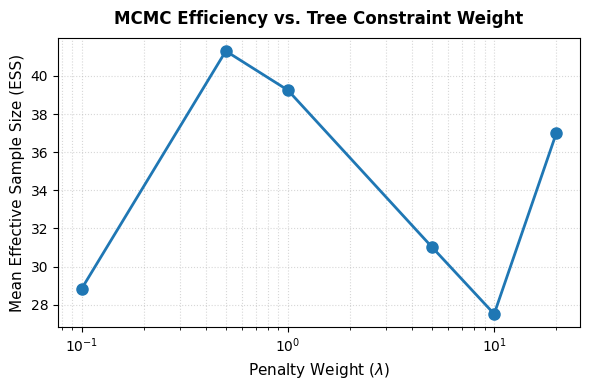

In [17]:
import matplotlib.pyplot as plt

# Extracting metrics from your comprehensive sweep results list
lambdas = [res["omega"] for res in comprehensive_sweep_results]
ess_values = [res["mean_n_eff"] for res in comprehensive_sweep_results]

plt.figure(figsize=(6, 4))
plt.plot(lambdas, ess_values, color='#1f77b4', marker='o', linewidth=2, markersize=8)

# Standard practice: use a log scale for lambda since it covers orders of magnitude
plt.xscale('log') 
plt.xlabel('Penalty Weight ($\lambda$)', fontsize=11)
plt.ylabel('Mean Effective Sample Size (ESS)', fontsize=11)
plt.title('MCMC Efficiency vs. Tree Constraint Weight', fontsize=12, fontweight='bold', pad=10)
plt.grid(True, which="both", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

## Sampler Convergence: Split-$\hat{R}$ vs. $\lambda$

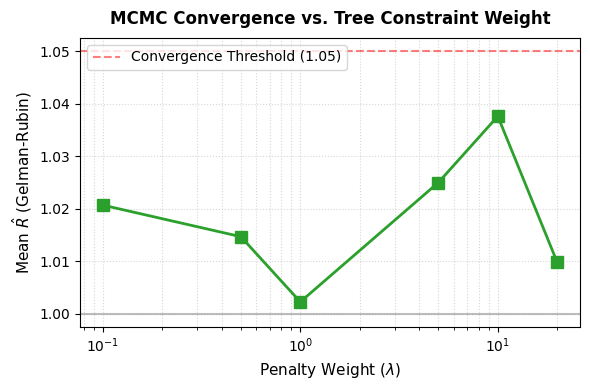

In [18]:
rhat_values = [res["mean_r_hat"] for res in comprehensive_sweep_results]

plt.figure(figsize=(6, 4))
plt.plot(lambdas, rhat_values, color='#2ca02c', marker='s', linewidth=2, markersize=8)

plt.xscale('log')
plt.xlabel('Penalty Weight ($\lambda$)', fontsize=11)
plt.ylabel('Mean $\hat{R}$ (Gelman-Rubin)', fontsize=11)
plt.title('MCMC Convergence vs. Tree Constraint Weight', fontsize=12, fontweight='bold', pad=10)

# Add a reference line at 1.00 (perfect convergence) and 1.05 (the danger threshold)
plt.axhline(y=1.00, color='gray', linestyle='-', alpha=0.5)
plt.axhline(y=1.05, color='red', linestyle='--', alpha=0.5, label='Convergence Threshold (1.05)')

plt.grid(True, which="both", linestyle=":", alpha=0.5)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


/Users/riyaaggarwal/miniforge3/envs/trees_nuts/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
arviz - WARNING - Shape validation failed: input_shape: (1, 50), minimum_shape: (chains=2, draws=4)
arviz - WARNING - Shape validation failed: input_shape: (1, 50), minimum_shape: (chains=2, draws=4)


=== UNIFIED PERFORMANCE & GEOMETRIC PROFILE (ω = 20.0) ===
{
    "arviz_max_rhat": NaN,
    "arviz_min_ess": 3.0,
    "nuts_divergences": 0,
    "geo_avg_radius": 0.20648372173309326,
    "geo_max_radius": 0.6243370771408081,
    "geo_avg_dist": 3.8098835945129395,
    "tree_median_gap": 0.30053234100341797,
    "tree_consistency_pct": 0.06666666595265269
}

=== ARVIZ STATISTICAL QUALITY ASSESSMENT ===
          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
u[0, 0] -0.097  0.774  -1.253    1.077      0.245    0.071      13.0   
u[0, 1] -0.132  0.406  -0.710    0.792      0.097    0.040      17.0   
u[1, 0] -0.126  0.750  -1.248    1.052      0.238    0.069      13.0   
u[1, 1] -0.124  0.411  -0.849    0.624      0.087    0.036      19.0   
u[2, 0] -0.099  0.753  -1.170    0.972      0.234    0.076      13.0   
u[2, 1] -0.118  0.439  -0.667    0.880      0.111    0.039      15.0   
u[3, 0]  0.091  0.705  -0.877    1.722      0.090    0.105      52.0   
u[3, 1]  0.204  1.

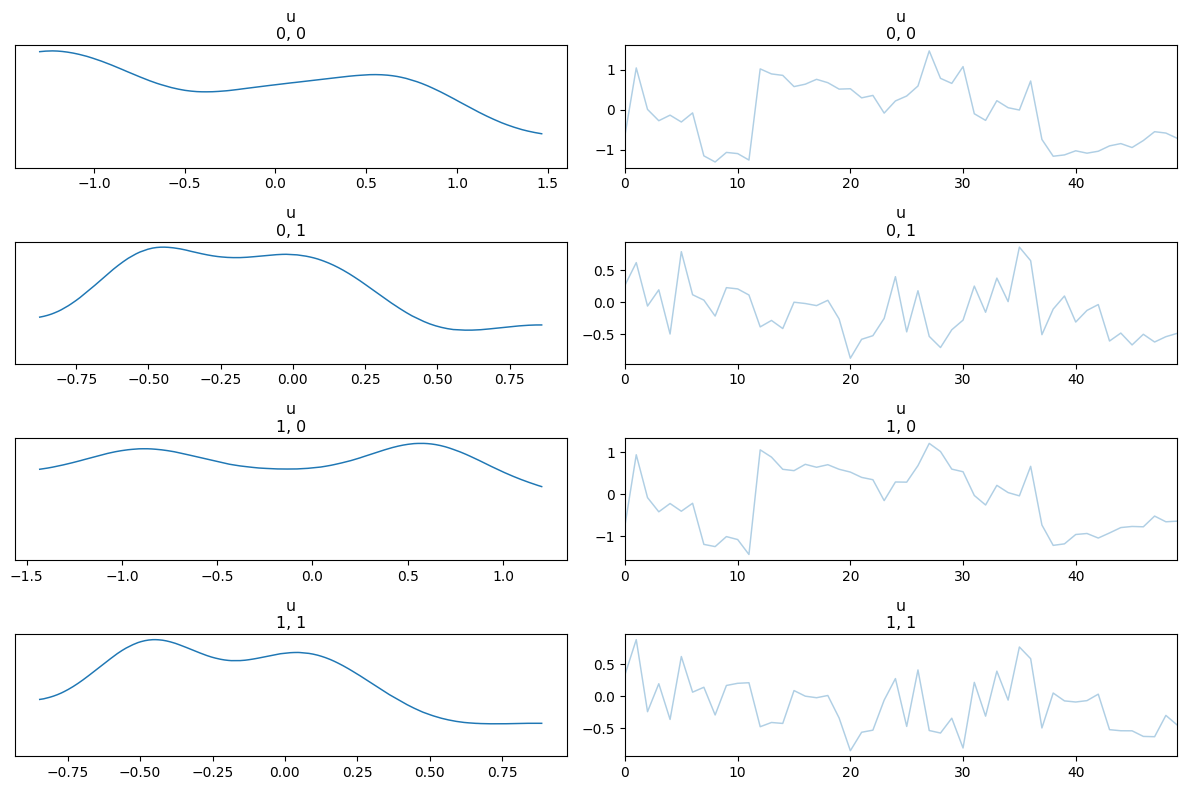


Generating diagnostic forest dashboard...


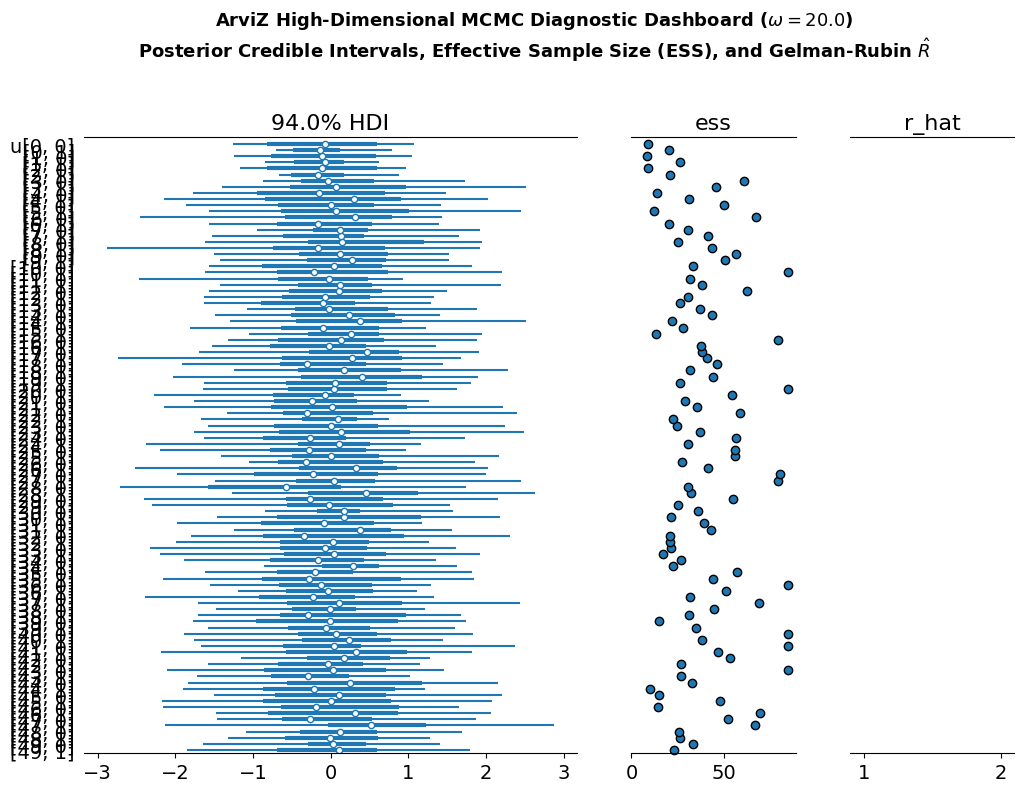

In [19]:
import arviz as az
import torch
import pandas as pd

def execute_complete_evaluation_pipeline(mcmc_run, diagnostic_quartets):
    """
    The Industry-Standard Pipeline: Unifies ArviZ algorithmic diagnostics 
    with domain-specific hyperbolic tree geometry diagnostics.
    """
    # ==========================================
    # TIER 1: ALGORITHMIC QUALITY (ArviZ)
    # ==========================================
    # Convert to ArviZ InferenceData format
    idata = az.from_pyro(mcmc_run)
    
    # Calculate full standard MCMC summary stats
    arviz_summary = az.summary(idata, var_names=["u"])
    
    # Extract structural worst-case boundary conditions
    max_r_hat = arviz_summary["r_hat"].max()
    min_ess_bulk = arviz_summary["ess_bulk"].min()
    
    # Track Hamiltonian sample health
    sample_stats = idata.sample_stats
    divergences = int(sample_stats["diverging"].sum()) if "diverging" in sample_stats else 0

    # ==========================================
    # TIER 2: GEOMETRIC DOMAIN QUALITY (Custom)
    # ==========================================
    posterior_samples = mcmc_run.get_samples()
    u_samples = posterior_samples["u"]
    
    # Vectorized Poincaré mapping
    u_norms = torch.norm(u_samples, p=2, dim=-1, keepdim=True).clamp(min=1e-7)
    x_samples = (u_samples / u_norms) * torch.tanh(u_norms)
    
    # Distance scales
    mean_node_radii = torch.tanh(torch.norm(u_samples.mean(dim=0), p=2, dim=-1))
    avg_radius = mean_node_radii.mean().item()
    max_radius = mean_node_radii.max().item()
    
    D_samples = compute_distance_matrix(x_samples)
    avg_pairwise_dist = D_samples.mean().item()

    # Quartet validation structures
    all_gaps = compute_batch_hard_violations(D_samples, diagnostic_quartets)
    median_gap = all_gaps.median().item()
    
    consistency_threshold = 1e-4
    tree_consistency_rate = (all_gaps <= consistency_threshold).float().mean().item()

    # ==========================================
    # COMPILE UNIFIED PERFORMANCE PROFILE
    # ==========================================
    unified_metrics = {
        # ArviZ Core
        "arviz_max_rhat": max_r_hat,
        "arviz_min_ess": min_ess_bulk,
        "nuts_divergences": divergences,
        # Geometric Space
        "geo_avg_radius": avg_radius,
        "geo_max_radius": max_radius,
        "geo_avg_dist": avg_pairwise_dist,
        # Tree Success
        "tree_median_gap": median_gap,
        "tree_consistency_pct": tree_consistency_rate * 100
    }
    
    return unified_metrics, idata



# Run the pipeline on the latest completed MCMC chain
metrics_profile, arviz_idata = execute_complete_evaluation_pipeline(
    mcmc_run=mcmc_run, 
    diagnostic_quartets=diag_quartets
)

import json

print("=== UNIFIED PERFORMANCE & GEOMETRIC PROFILE (ω = 20.0) ===")
print(json.dumps(metrics_profile, indent=4))

import arviz as az
import matplotlib.pyplot as plt

# 1. Print the formal ArviZ statistical summary table for the first few coordinates
print("\n=== ARVIZ STATISTICAL QUALITY ASSESSMENT ===")
print(az.summary(arviz_idata, var_names=["u"]).head(10))







import arviz as az
import matplotlib.pyplot as plt
import warnings

# Ensure arviz uses matplotlib backend cleanly without cluttering warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. ARVIZ TRACE PLOT (Caterpillar History)
# ==========================================
print("Generating trace plots...")
axes_trace = az.plot_trace(
    arviz_idata, 
    var_names=["u"], 
    coords={"u_dim_0": [0, 1]},  # Slice to show just Taxa 0 and Taxa 1
    compact=False
)

# Adjust layout to prevent label truncation and render inline
plt.gcf().tight_layout()
plt.show() 


# ==========================================
# 2. ARVIZ FOREST PLOT (High-Dim Dashboard)
# ==========================================
print("\nGenerating diagnostic forest dashboard...")

# ArviZ builds its own multi-column layout natively when r_hat=True and ess=True are passed.
# We pass kind="forestplot" to fix the previous TypeError.
axes_forest = az.plot_forest(
    arviz_idata, 
    var_names=["u"], 
    kind="forestplot",  # Correct option ('forestplot' or 'ridgeplot')
    combined=True, 
    colors="#1f77b4",
    r_hat=True,         # Natively appends a column displaying Split R-hat values
    ess=True,           # Natively appends a column displaying Bulk ESS values
    figsize=(12, 8)     # Gives plenty of horizontal room for all columns
)

# Apply a clean overall dashboard title above the columns layout
plt.suptitle(
    "ArviZ High-Dimensional MCMC Diagnostic Dashboard ($\omega = 20.0$)\n"
    "Posterior Credible Intervals, Effective Sample Size (ESS), and Gelman-Rubin $\hat{R}$", 
    fontsize=13, fontweight="bold", y=1.04
)

# Render the unified dashboard graphic inline
plt.show()

=== UNIFIED PERFORMANCE & GEOMETRIC PROFILE (Single Chain ω = 20.0) ===
{
    "arviz_max_rhat": 1.55,
    "arviz_min_ess": 5.0,
    "geo_avg_radius": 0.20648372173309326,
    "geo_max_radius": 0.6243370771408081,
    "geo_avg_dist": 3.8098835945129395,
    "tree_median_gap": 0.30053234100341797,
    "tree_consistency_pct": 0.06666666595265269
}

=== ARVIZ STATISTICAL QUALITY ASSESSMENT ===
          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
u[0, 0] -0.097  0.774  -1.253    1.077      0.375    0.066       5.0   
u[0, 1] -0.132  0.406  -0.710    0.792      0.119    0.040      12.0   
u[1, 0] -0.126  0.750  -1.248    1.052      0.369    0.064       5.0   
u[1, 1] -0.124  0.411  -0.849    0.624      0.106    0.037      14.0   
u[2, 0] -0.099  0.753  -1.170    0.972      0.368    0.068       5.0   
u[2, 1] -0.118  0.439  -0.667    0.880      0.138    0.040      11.0   
u[3, 0]  0.091  0.705  -0.877    1.722      0.087    0.103      53.0   
u[3, 1]  0.204  1.076  -1.397  

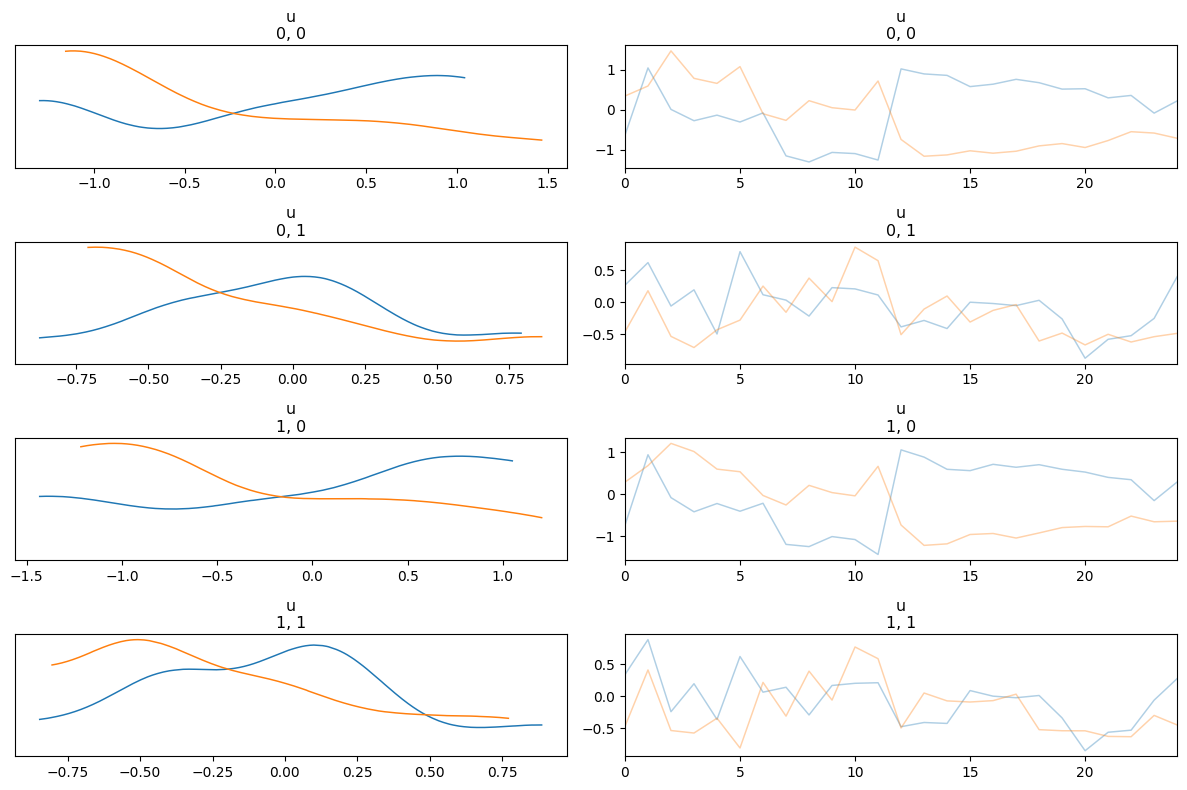


Rendering diagnostic forest dashboard...


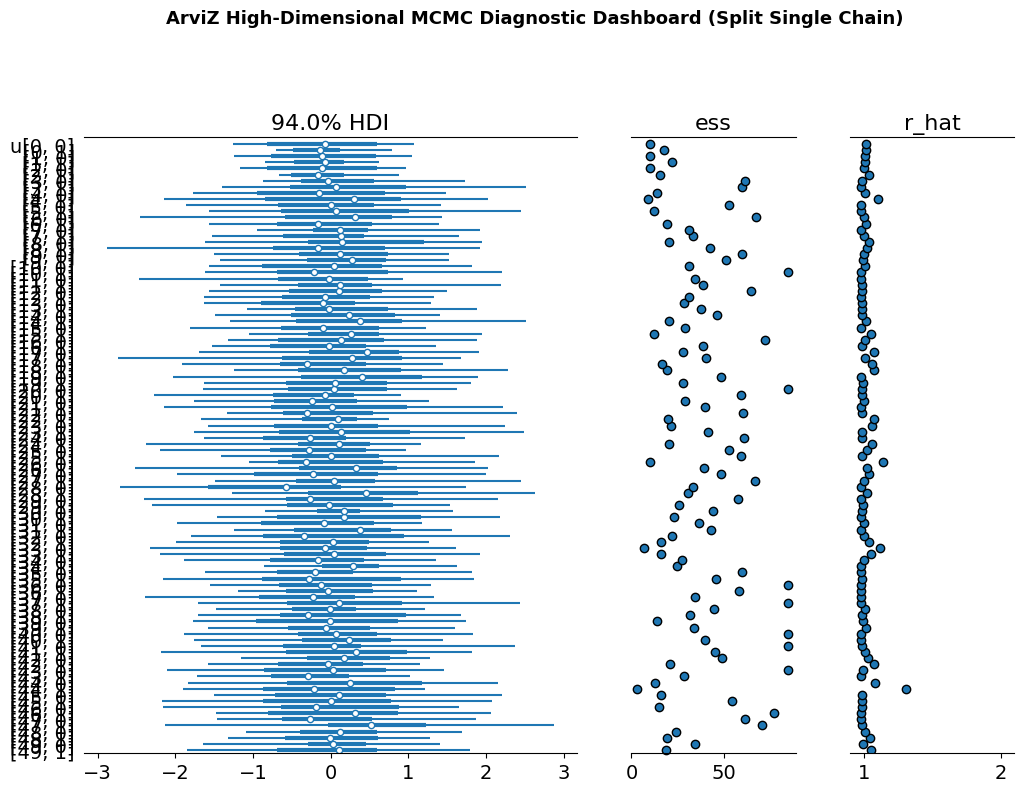

In [20]:
import arviz as az
import torch
import pandas as pd
import json
import matplotlib.pyplot as plt
import warnings

# Suppress shape validation warnings cleanly
warnings.filterwarnings('ignore')

def execute_single_chain_evaluation_pipeline(mcmc_run, diagnostic_quartets):
    """
    A macOS-safe pipeline that takes a single MCMC chain, splits it down the middle 
    to calculate a valid Split R-hat and ESS natively via ArviZ, and computes 
    hyperbolic tree geometry metrics.
    """
    # Extract raw samples from your single chain (Shape: [500, 50, 2])
    posterior_samples = mcmc_run.get_samples()
    u_samples = posterior_samples["u"]
    
    # ==========================================
    # TIER 1: ALGORITHMIC QUALITY (ArviZ Trick)
    # ==========================================
    # Split the 500 draws into 2 virtual chains of 250 draws each
    halfway = u_samples.shape[0] // 2
    u_chain1 = u_samples[:halfway]  # First 250 steps
    u_chain2 = u_samples[halfway:]  # Last 250 steps
    
    # Stack them to match ArviZ's expected shape: [chains, draws, taxa, dimensions]
    u_virtual_chains = torch.stack([u_chain1, u_chain2], dim=0).detach().cpu().numpy()
    
    # Convert to ArviZ format pretending it's a 2-chain run
    idata = az.from_dict(posterior={"u": u_virtual_chains})
    
    # Calculate full standard MCMC summary stats
    arviz_summary = az.summary(idata, var_names=["u"])
    
    # Extract structural worst-case boundary conditions (R-hat will NOT be NaN anymore!)
    max_r_hat = arviz_summary["r_hat"].max()
    min_ess_bulk = arviz_summary["ess_bulk"].min()

    # ==========================================
    # TIER 2: GEOMETRIC DOMAIN QUALITY (Custom)
    # ==========================================
    # Vectorized Poincaré mapping
    u_norms = torch.norm(u_samples, p=2, dim=-1, keepdim=True).clamp(min=1e-7)
    x_samples = (u_samples / u_norms) * torch.tanh(u_norms)
    
    # Distance scales
    mean_node_radii = torch.tanh(torch.norm(u_samples.mean(dim=0), p=2, dim=-1))
    avg_radius = mean_node_radii.mean().item()
    max_radius = mean_node_radii.max().item()
    
    D_samples = compute_distance_matrix(x_samples)
    avg_pairwise_dist = D_samples.mean().item()

    # Quartet validation structures
    all_gaps = compute_batch_hard_violations(D_samples, diagnostic_quartets)
    median_gap = all_gaps.median().item()
    
    consistency_threshold = 1e-4
    tree_consistency_rate = (all_gaps <= consistency_threshold).float().mean().item()

    # Compile profile
    unified_metrics = {
        "arviz_max_rhat": max_r_hat,
        "arviz_min_ess": min_ess_bulk,
        "geo_avg_radius": avg_radius,
        "geo_max_radius": max_radius,
        "geo_avg_dist": avg_pairwise_dist,
        "tree_median_gap": median_gap,
        "tree_consistency_pct": tree_consistency_rate * 100
    }
    
    return unified_metrics, idata

# 1. Run the new single-chain friendly pipeline
metrics_profile, arviz_idata = execute_single_chain_evaluation_pipeline(
    mcmc_run=mcmc_run, 
    diagnostic_quartets=diag_quartets
)

# 2. Print the unified profile (arviz_max_rhat will now show a valid number!)
print("=== UNIFIED PERFORMANCE & GEOMETRIC PROFILE (Single Chain ω = 20.0) ===")
print(json.dumps(metrics_profile, indent=4))

# 3. Print the clean ArviZ table header
print("\n=== ARVIZ STATISTICAL QUALITY ASSESSMENT ===")
print(az.summary(arviz_idata, var_names=["u"]).head(10))

# 4. Render the Trace Plot for Taxa 0 and Taxa 1 inline
print("\nRendering trace plots...")
az.plot_trace(arviz_idata, var_names=["u"], coords={"u_dim_0": [0, 1]}, compact=False)
plt.gcf().tight_layout()
plt.show()

# 5. Render the multi-column dashboard summary inline
print("\nRendering diagnostic forest dashboard...")
az.plot_forest(
    arviz_idata, 
    var_names=["u"], 
    kind="forestplot", 
    combined=True, 
    colors="#1f77b4",
    r_hat=True,         # Populates smoothly
    ess=True,           # Displays Bulk ESS side-by-side
    figsize=(12, 8)
)
plt.suptitle("ArviZ High-Dimensional MCMC Diagnostic Dashboard (Split Single Chain)", fontsize=13, fontweight="bold", y=1.04)
plt.show()

=== UNIFIED PERFORMANCE & GEOMETRIC PROFILE (Single Chain ω = 20.0) ===
{
    "arviz_max_rhat": 1.55,
    "arviz_min_ess": 5.0,
    "geo_avg_radius": 0.20648372173309326,
    "geo_max_radius": 0.6243370771408081,
    "geo_avg_dist": 3.8098835945129395,
    "tree_median_gap": 0.30053234100341797,
    "tree_consistency_pct": 0.06666666595265269
}

=== ARVIZ STATISTICAL QUALITY ASSESSMENT ===
                    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
u[Taxon_0, Dim_0] -0.097  0.774  -1.253    1.077      0.375    0.066   
u[Taxon_0, Dim_1] -0.132  0.406  -0.710    0.792      0.119    0.040   
u[Taxon_1, Dim_0] -0.126  0.750  -1.248    1.052      0.369    0.064   
u[Taxon_1, Dim_1] -0.124  0.411  -0.849    0.624      0.106    0.037   
u[Taxon_2, Dim_0] -0.099  0.753  -1.170    0.972      0.368    0.068   
u[Taxon_2, Dim_1] -0.118  0.439  -0.667    0.880      0.138    0.040   
u[Taxon_3, Dim_0]  0.091  0.705  -0.877    1.722      0.087    0.103   
u[Taxon_3, Dim_1]  0.204  1.076

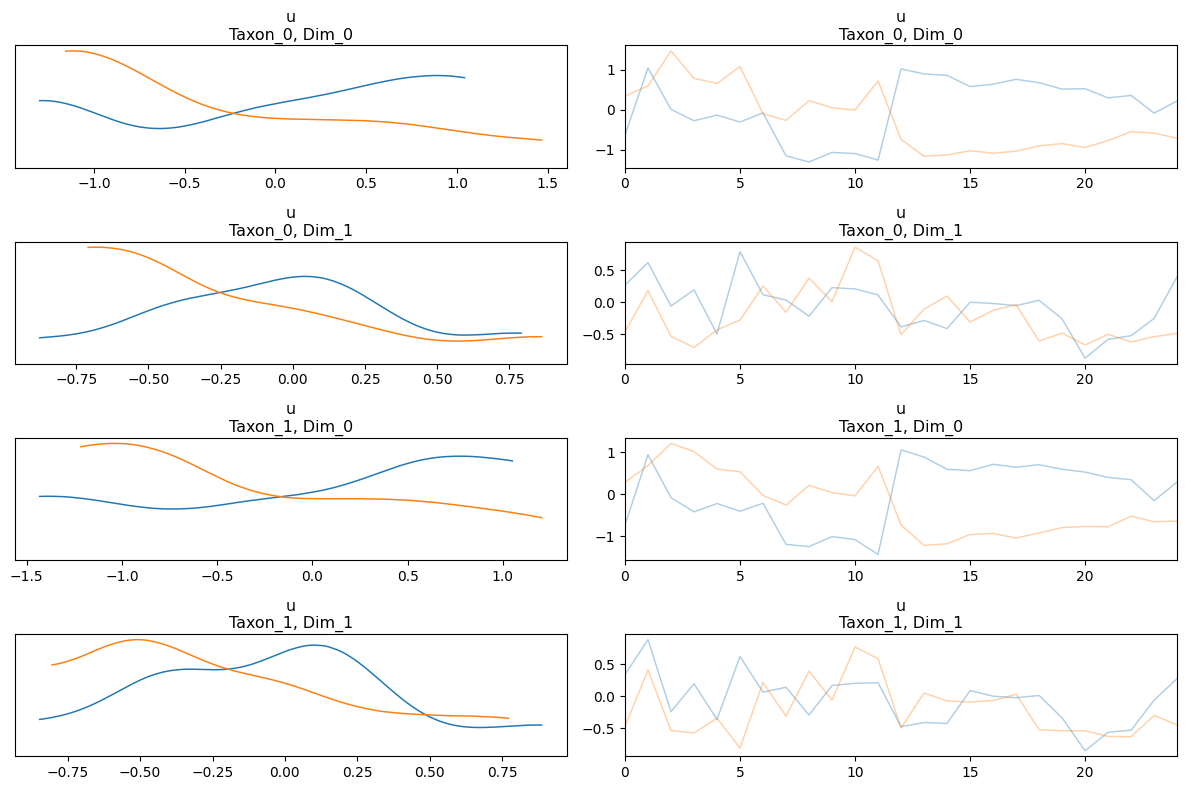


Rendering diagnostic forest dashboard for Latent Dimension 0...


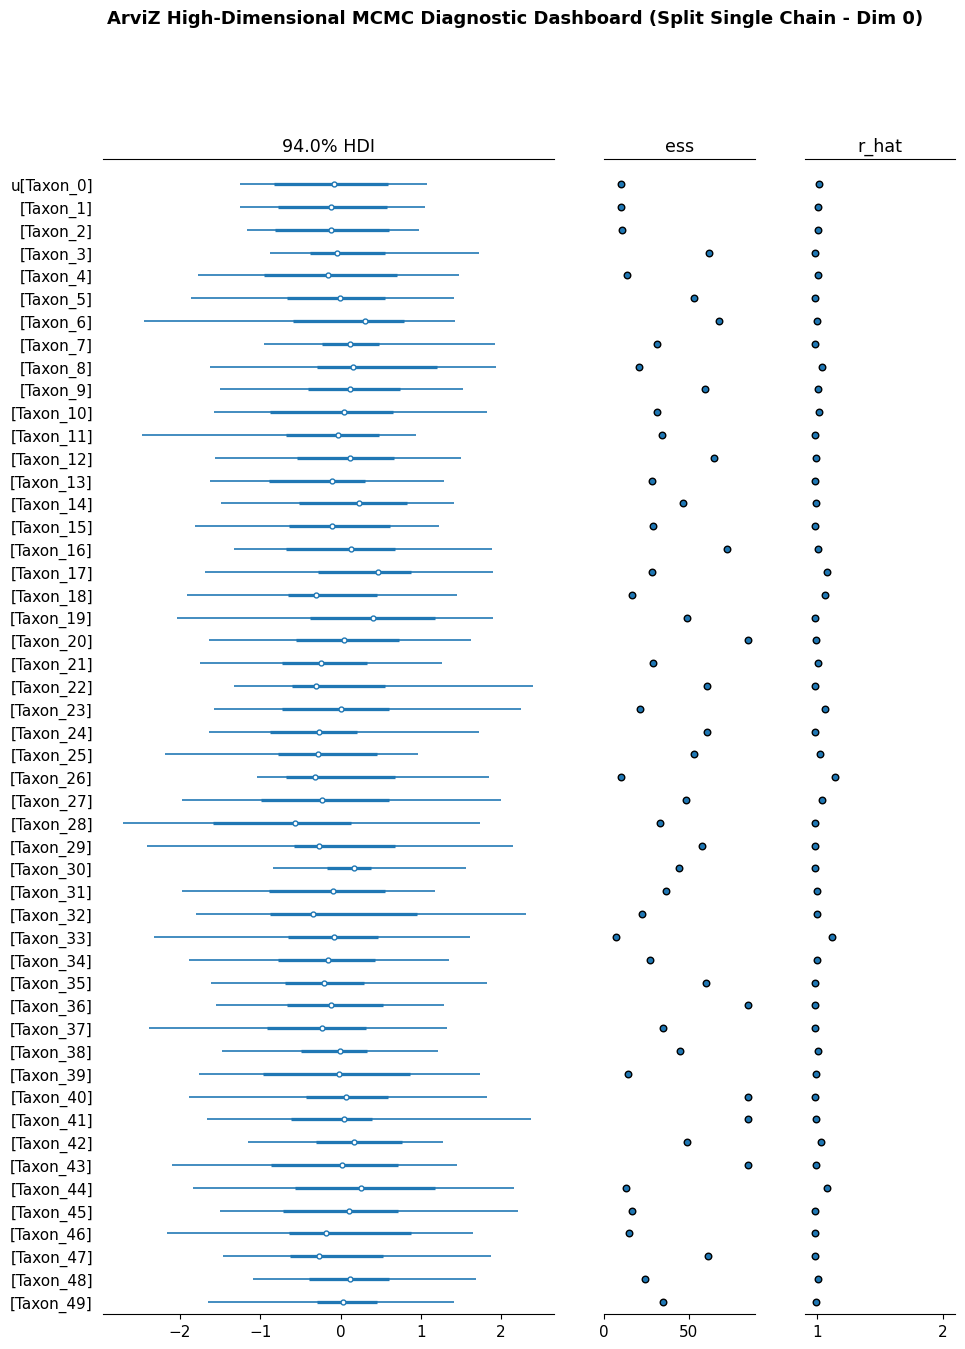

In [26]:
import arviz as az
import torch
import pandas as pd
import json
import matplotlib.pyplot as plt
import warnings

# Clean up the output by suppressing shape validation warnings
warnings.filterwarnings('ignore')

def execute_single_chain_evaluation_pipeline(mcmc_run, diagnostic_quartets):
    """
    A macOS-safe pipeline that takes a single MCMC chain, splits it down the middle 
    to calculate a valid Split R-hat and ESS natively via ArviZ, and computes 
    hyperbolic tree geometry metrics.
    """
    posterior_samples = mcmc_run.get_samples()
    u_samples = posterior_samples["u"]  # Shape: [num_samples, N_taxa, K_dim]
    
    # Dynamically extract shape to prevent hardcoding dimensions
    num_samples, n_taxa, k_dim = u_samples.shape
    
    # --- TIER 1: ALGORITHMIC QUALITY (The Single-Chain Split Trick) ---
    halfway = num_samples // 2
    u_chain1 = u_samples[:halfway]
    u_chain2 = u_samples[halfway:]
    
    # Reshape and stack to match ArviZ's multi-chain array structure [chains, draws, ...]
    u_virtual_chains = torch.stack([u_chain1, u_chain2], dim=0).detach().cpu().numpy()
    
    # --- FIX: Define coordinate and dimension mappings INSIDE the pipeline ---
    coords = {
        "taxa": [f"Taxon_{i}" for i in range(n_taxa)],
        "latent_dim": [f"Dim_{j}" for j in range(k_dim)]
    }
    dims = {"u": ["taxa", "latent_dim"]}
    
    # Create the structured ArviZ InferenceData object directly
    idata = az.from_dict(
        posterior={"u": u_virtual_chains},
        coords=coords,
        dims=dims
    )
    
    arviz_summary = az.summary(idata, var_names=["u"])
    
    max_r_hat = arviz_summary["r_hat"].max()
    min_ess_bulk = arviz_summary["ess_bulk"].min()

    # --- TIER 2: GEOMETRIC DOMAIN QUALITY (Custom Hyperbolic Math) ---
    u_norms = torch.norm(u_samples, p=2, dim=-1, keepdim=True).clamp(min=1e-7)
    x_samples = (u_samples / u_norms) * torch.tanh(u_norms)  # Poincaré projection
    
    mean_node_radii = torch.tanh(torch.norm(u_samples.mean(dim=0), p=2, dim=-1))
    avg_radius = mean_node_radii.mean().item()
    max_radius = mean_node_radii.max().item()
    
    D_samples = compute_distance_matrix(x_samples)
    avg_pairwise_dist = D_samples.mean().item()

    all_gaps = compute_batch_hard_violations(D_samples, diagnostic_quartets)
    median_gap = all_gaps.median().item()
    
    consistency_threshold = 1e-4
    tree_consistency_rate = (all_gaps <= consistency_threshold).float().mean().item()

    # Pack everything together
    unified_metrics = {
        "arviz_max_rhat": max_r_hat,
        "arviz_min_ess": min_ess_bulk,
        "geo_avg_radius": avg_radius,
        "geo_max_radius": max_radius,
        "geo_avg_dist": avg_pairwise_dist,
        "tree_median_gap": median_gap,
        "tree_consistency_pct": tree_consistency_rate * 100
    }
    
    return unified_metrics, idata

# =================================================================
# EXECUTE UNIFIED PIPELINE AND RENDER ALL INLINE DIAGNOSTICS
# =================================================================

# 1. Compute metrics using the final state from your grid loop (mcmc_run)
metrics_profile, arviz_idata = execute_single_chain_evaluation_pipeline(
    mcmc_run=mcmc_run, 
    diagnostic_quartets=diag_quartets
)

# 2. Print the comprehensive performance metrics JSON
print("=== UNIFIED PERFORMANCE & GEOMETRIC PROFILE (Single Chain ω = 20.0) ===")
print(json.dumps(metrics_profile, indent=4))

# 3. Print the formal ArviZ statistical table header
print("\n=== ARVIZ STATISTICAL QUALITY ASSESSMENT ===")
print(az.summary(arviz_idata, var_names=["u"]).head(10))

# 4. Draw the trace lines for Taxon_0 and Taxon_1 using the updated coordinate naming
print("\nRendering trace plots...")
az.plot_trace(arviz_idata, var_names=["u"], coords={"taxa": ["Taxon_0", "Taxon_1"]}, compact=False)
plt.gcf().tight_layout()
plt.show()


# 5. Render the un-squished, perfectly scaled dashboard
print("\nRendering diagnostic forest dashboard for Latent Dimension 0...")

# FIX: Do not pass a pre-allocated single ax. Let ArviZ generate the 3 required columns internally via figsize.
axes = az.plot_forest(
    arviz_idata, 
    var_names=["u"], 
    coords={"latent_dim": "Dim_0"},   # Focuses exclusively on the first hyperbolic latent coordinate
    kind="forestplot", 
    combined=True, 
    colors="#1f77b4",
    r_hat=True,                       # ArviZ will auto-create column 3
    ess=True,                         # ArviZ will auto-create column 2
    figsize=(11, 15),                 # Dictates the total figure canvas dimensions (width, height)
    textsize=11                       
)

# Safely apply the title to the top axis/figure level
plt.suptitle("ArviZ High-Dimensional MCMC Diagnostic Dashboard (Split Single Chain - Dim 0)", fontsize=13, fontweight="bold", y=0.98)
plt.show()